# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-30 14:28:19.878701: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-30 14:28:20.238752: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-30 14:28:20.238871: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-30 14:28:20.241162: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-30 14:28:20.435166: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-30 14:28:20.437901: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

Python executable: /home/pedleyhuang/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32)
    X_test  = np.loadtxt(os.path.join(root_dir, "test",  "X_test.txt"),  dtype=np.float32)
    y_test  = np.loadtxt(os.path.join(root_dir, "test",  "y_test.txt"),  dtype=np.int32)
    # Convert to zero-based class indices
    y_train -= 1
    y_test  -= 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

num_features = X_train.shape[1]
num_classes  = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape)
print("y_test  shape:", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test  shape: (2947, 561)
y_test  shape: (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection

In [ ]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name":  class_names,
    "Training Samples": label_counts.values,
})
print(summary_df.to_string(index=False))


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [4]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


2026-04-30 15:09:05.612192: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-30 15:09:05.612987: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 8ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

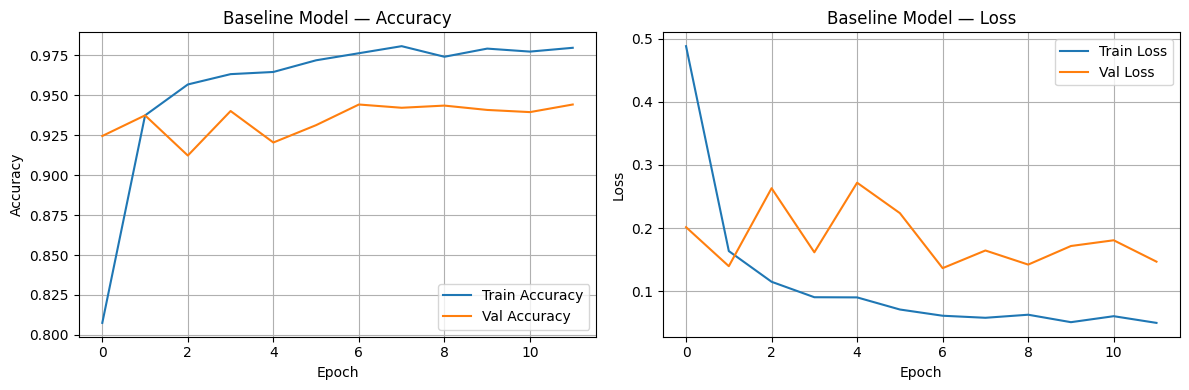

In [6]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

history_df = pd.DataFrame(baseline_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["accuracy"],     label="Train Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Val Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline Model — Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_df["loss"],     label="Train Loss")
axes[1].plot(history_df["val_loss"], label="Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Baseline Model — Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 6. Evaluate the Baseline Keras Model

Baseline Test Accuracy: 0.9243

                    precision    recall  f1-score   support

           WALKING     0.9042    0.9899    0.9451       496
  WALKING_UPSTAIRS     0.8835    0.9342    0.9082       471
WALKING_DOWNSTAIRS     0.9885    0.8190    0.8958       420
           SITTING     0.9315    0.8859    0.9081       491
          STANDING     0.8666    0.9398    0.9017       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9243      2947
         macro avg     0.9291    0.9210    0.9228      2947
      weighted avg     0.9281    0.9243    0.9242      2947



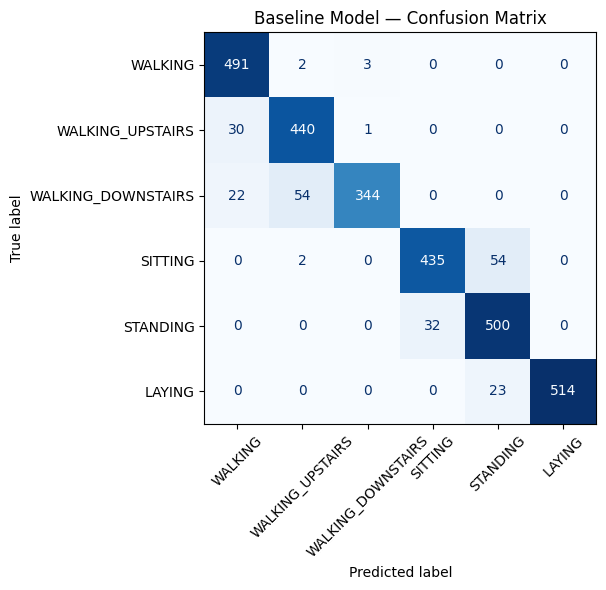

In [7]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc   = accuracy_score(y_test, baseline_preds)

print(f"Baseline Test Accuracy: {baseline_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Model — Confusion Matrix")
plt.tight_layout()
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [8]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize input when the model expects int8 or uint8
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize output when it is int8 or uint8
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [9]:
# Convert baseline to FP32 TFLite
baseline_fp32_tflite  = convert_to_tflite_fp32(baseline_model)
baseline_fp32_size_kb = save_binary_model(baseline_fp32_tflite, "baseline_fp32.tflite")
baseline_fp32_acc, _  = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)

print(f"Baseline FP32 TFLite  — Accuracy: {baseline_fp32_acc:.4f}  Size: {baseline_fp32_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpsjju_jfq/assets


INFO:tensorflow:Assets written to: /tmp/tmpsjju_jfq/assets


Baseline FP32 TFLite  — Accuracy: 0.9243  Size: 726.72 KB


2026-04-30 15:11:55.463626: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-30 15:11:55.463715: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-30 15:11:55.464307: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpsjju_jfq
2026-04-30 15:11:55.465561: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-30 15:11:55.465581: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpsjju_jfq
2026-04-30 15:11:55.474631: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-30 15:11:55.475538: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-30 15:11:55.530981: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpsjju_jfq
2026-04

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [10]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params,
)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

pruned_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)


Epoch 1/12
92/92 [==============================] - 3s 9ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1662 - accuracy: 0.9373 - val_loss: 0.1596 - val_accuracy: 0.9286
Epoch 3/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1310 - accuracy: 0.9493 - val_loss: 0.2198 - val_accuracy: 0.9279
Epoch 4/12
92/92 [==============================] - 1s 6ms/step - loss: 0.0920 - accuracy: 0.9691 - val_loss: 0.1562 - val_accuracy: 0.9354
Epoch 5/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1559 - accuracy: 0.9429 - val_loss: 0.1403 - val_accuracy: 0.9395
Epoch 6/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1319 - accuracy: 0.9565 - val_loss: 0.1508 - val_accuracy: 0.9334
Epoch 7/12
92/92 [==============================] - 1s 6ms/step - loss: 0.3422 - accuracy: 0.9221 - val_loss: 0.1753 - val_accuracy: 0.9313
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [11]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# 1. FP32 TFLite with pruning mask still attached
pruned_with_mask_tflite  = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, _  = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

print(f"Pruned FP32 (with mask) — Accuracy: {pruned_with_mask_acc:.4f}  Size: {pruned_with_mask_size_kb:.2f} KB")

# 2. Strip wrappers, then convert with EXPERIMENTAL_SPARSITY
stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite  = converter.convert()
stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Stripped Sparse FP32   — Accuracy: {stripped_sparse_acc:.4f}  Size: {stripped_sparse_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpuhb6j17p/assets


INFO:tensorflow:Assets written to: /tmp/tmpuhb6j17p/assets
2026-04-30 15:14:36.094078: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-30 15:14:36.094144: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-30 15:14:36.094327: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpuhb6j17p
2026-04-30 15:14:36.099635: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-30 15:14:36.099654: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpuhb6j17p
2026-04-30 15:14:36.116925: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-30 15:14:36.178510: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpuhb6j17p
2026-04-30 15:14:36.197984: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Pruned FP32 (with mask) — Accuracy: 0.9230  Size: 1454.18 KB
INFO:tensorflow:Assets written to: /tmp/tmp2xkp_c84/assets


INFO:tensorflow:Assets written to: /tmp/tmp2xkp_c84/assets


Stripped Sparse FP32   — Accuracy: 0.9230  Size: 338.85 KB


2026-04-30 15:14:37.233409: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-30 15:14:37.233471: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-30 15:14:37.233726: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp2xkp_c84
2026-04-30 15:14:37.234257: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-30 15:14:37.234269: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp2xkp_c84
2026-04-30 15:14:37.235692: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-30 15:14:37.251133: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp2xkp_c84
2026-04-30 15:14:37.257063: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 23340 m

## 11. Part I Comparison: Accuracy and Model Size

In [12]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

part1_results = pd.DataFrame([
    ["Baseline",            "FP32",           baseline_fp32_acc,    baseline_fp32_size_kb],
    ["Pruned (with mask)",  "FP32",           pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse",     "FP32 + Sparse",  stripped_sparse_acc,  stripped_sparse_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

print(part1_results.to_string(index=False))


             Model        Format  Test Accuracy  Model Size (KB)
          Baseline          FP32       0.924330       726.718750
Pruned (with mask)          FP32       0.922973      1454.175781
   Stripped Sparse FP32 + Sparse       0.922973       338.851562


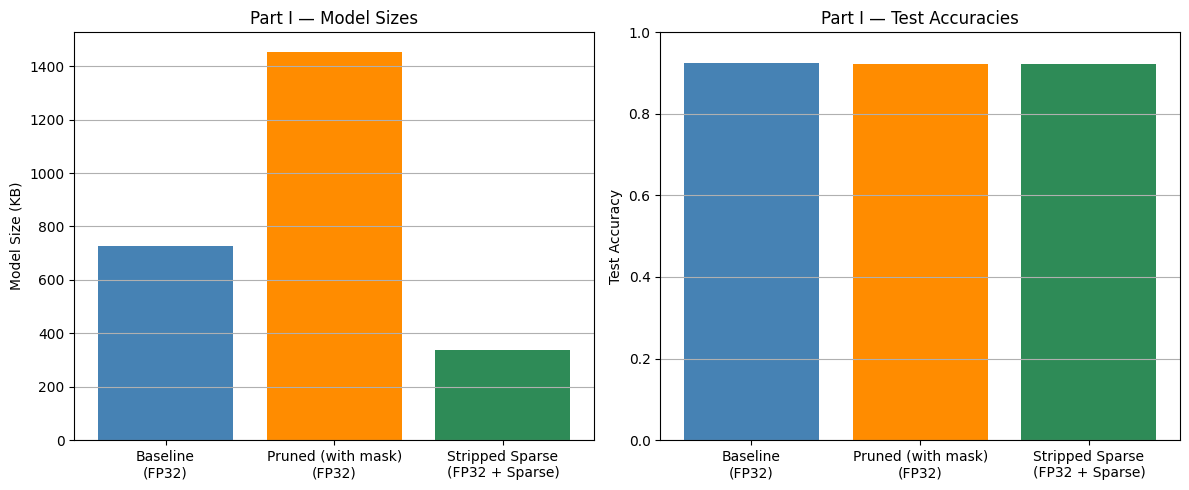

In [13]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

labels = [f"{r['Model']}\n({r['Format']})" for _, r in part1_results.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, part1_results["Model Size (KB)"], color=["steelblue", "darkorange", "seagreen"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part I — Model Sizes")
axes[0].grid(axis="y")

axes[1].bar(labels, part1_results["Test Accuracy"], color=["steelblue", "darkorange", "seagreen"])
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0, 1)
axes[1].set_title("Part I — Test Accuracies")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse Model

Stripped Sparse FP32 — Classification Report
                    precision    recall  f1-score   support

           WALKING     0.9289    0.9476    0.9381       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.8963    0.9262    0.9110       420
           SITTING     0.9341    0.8656    0.8985       491
          STANDING     0.8465    0.9436    0.8924       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9230      2947
         macro avg     0.9250    0.9221    0.9227      2947
      weighted avg     0.9257    0.9230    0.9234      2947



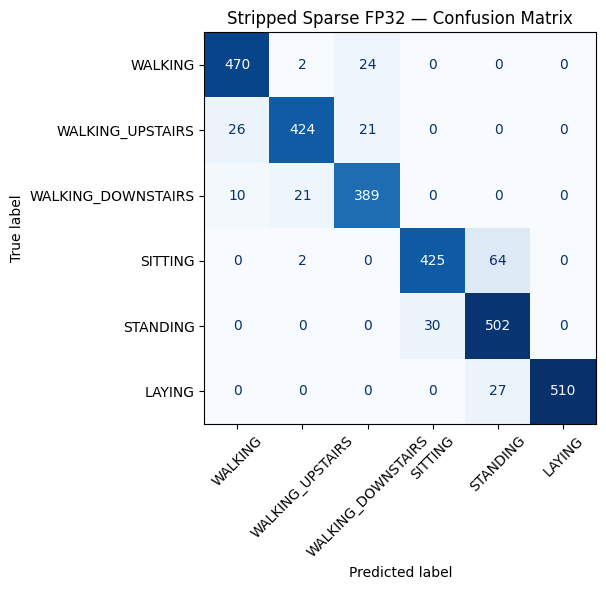

In [14]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

print("Stripped Sparse FP32 — Classification Report")
print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse FP32 — Confusion Matrix")
plt.tight_layout()
plt.show()


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [15]:
# 1. Pruned model with mask — float16
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_fp16_with_mask_tflite  = converter.convert()
pruned_fp16_with_mask_size_kb = save_binary_model(pruned_fp16_with_mask_tflite, "pruned_with_mask_fp16.tflite")
pruned_fp16_with_mask_acc, _  = evaluate_tflite_model(pruned_fp16_with_mask_tflite, X_test, y_test)

print(f"Pruned FP16 (with mask)      — Accuracy: {pruned_fp16_with_mask_acc:.4f}  Size: {pruned_fp16_with_mask_size_kb:.2f} KB")

# 2. Stripped sparse model — float16
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_fp16_tflite  = converter.convert()
stripped_sparse_fp16_size_kb = save_binary_model(stripped_sparse_fp16_tflite, "stripped_sparse_fp16.tflite")
stripped_sparse_fp16_acc, stripped_sparse_fp16_preds = evaluate_tflite_model(
    stripped_sparse_fp16_tflite, X_test, y_test
)

print(f"Stripped Sparse FP16         — Accuracy: {stripped_sparse_fp16_acc:.4f}  Size: {stripped_sparse_fp16_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpbavw63he/assets


INFO:tensorflow:Assets written to: /tmp/tmpbavw63he/assets
2026-04-30 15:16:02.048668: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-30 15:16:02.048762: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-30 15:16:02.049002: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpbavw63he
2026-04-30 15:16:02.052712: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-30 15:16:02.052729: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpbavw63he
2026-04-30 15:16:02.061868: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-30 15:16:02.122356: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpbavw63he
2026-04-30 15:16:02.141909: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Pruned FP16 (with mask)      — Accuracy: 0.9230  Size: 732.59 KB
INFO:tensorflow:Assets written to: /tmp/tmpksaeo8ge/assets


INFO:tensorflow:Assets written to: /tmp/tmpksaeo8ge/assets
2026-04-30 15:16:03.193715: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-30 15:16:03.193772: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Stripped Sparse FP16         — Accuracy: 0.9230  Size: 223.71 KB


2026-04-30 15:16:03.193935: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpksaeo8ge
2026-04-30 15:16:03.194466: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-30 15:16:03.194479: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpksaeo8ge
2026-04-30 15:16:03.195810: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-30 15:16:03.211652: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpksaeo8ge
2026-04-30 15:16:03.218065: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 24129 microseconds.


## 12. Part II Comparison: Accuracy and Model Size

In [16]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

part2_results = pd.DataFrame([
    ["Pruned (with mask)",  "FP32",          pruned_with_mask_acc,      pruned_with_mask_size_kb],
    ["Stripped Sparse",     "FP32 + Sparse", stripped_sparse_acc,       stripped_sparse_size_kb],
    ["Pruned (with mask)",  "FP16",          pruned_fp16_with_mask_acc, pruned_fp16_with_mask_size_kb],
    ["Stripped Sparse",     "FP16 + Sparse", stripped_sparse_fp16_acc,  stripped_sparse_fp16_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

print(part2_results.to_string(index=False))


             Model        Format  Test Accuracy  Model Size (KB)
Pruned (with mask)          FP32       0.922973      1454.175781
   Stripped Sparse FP32 + Sparse       0.922973       338.851562
Pruned (with mask)          FP16       0.922973       732.585938
   Stripped Sparse FP16 + Sparse       0.922973       223.710938


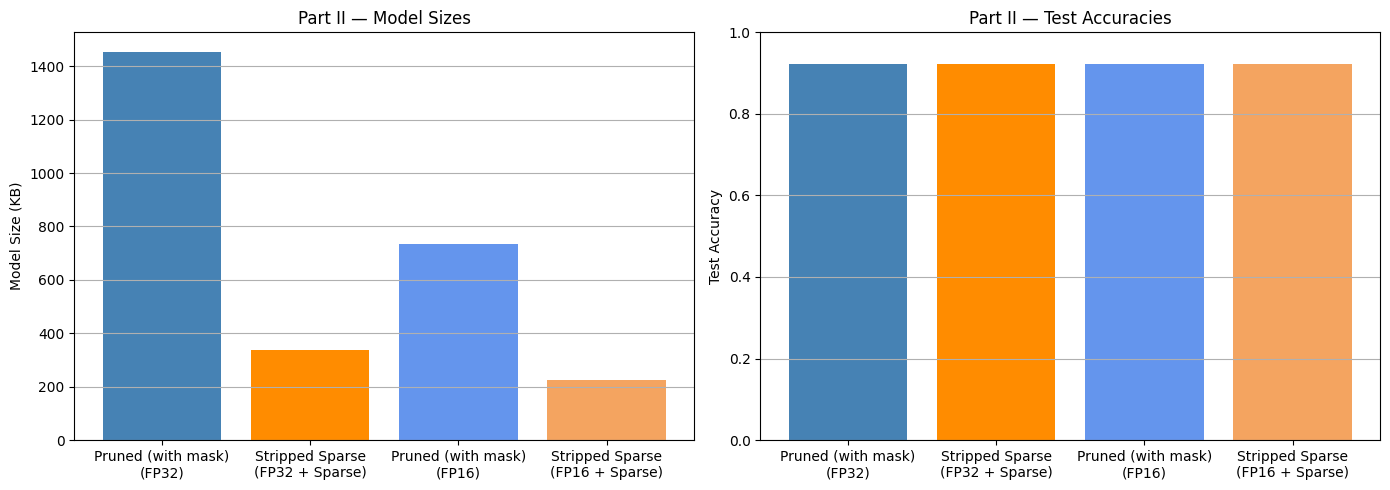

In [17]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

labels2 = [f"{r['Model']}\n({r['Format']})" for _, r in part2_results.iterrows()]
colors2  = ["steelblue", "darkorange", "cornflowerblue", "sandybrown"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels2, part2_results["Model Size (KB)"], color=colors2)
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part II — Model Sizes")
axes[0].grid(axis="y")

axes[1].bar(labels2, part2_results["Test Accuracy"], color=colors2)
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0, 1)
axes[1].set_title("Part II — Test Accuracies")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

Stripped Sparse FP16 — Classification Report
                    precision    recall  f1-score   support

           WALKING     0.9289    0.9476    0.9381       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.8963    0.9262    0.9110       420
           SITTING     0.9341    0.8656    0.8985       491
          STANDING     0.8465    0.9436    0.8924       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9230      2947
         macro avg     0.9250    0.9221    0.9227      2947
      weighted avg     0.9257    0.9230    0.9234      2947



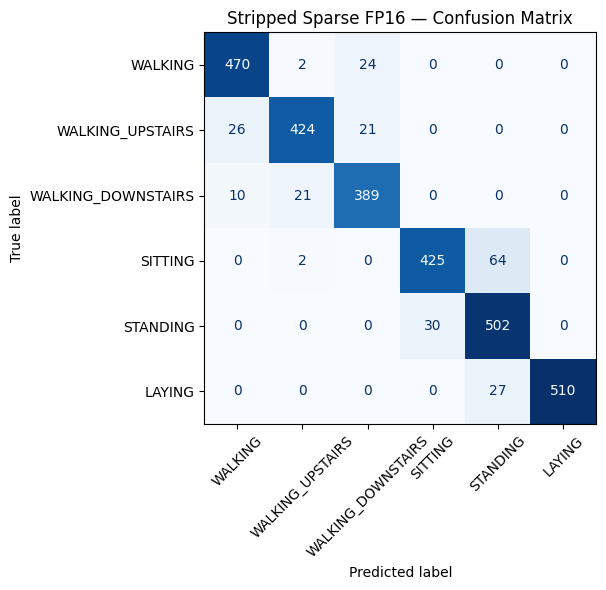

In [18]:
print("Stripped Sparse FP16 — Classification Report")
print(classification_report(y_test, stripped_sparse_fp16_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_fp16_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse FP16 — Confusion Matrix")
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
2. Why does `strip_pruning(...)` matter before export?
3. Which model had the smallest file size in this notebook?
4. Did float16 quantization noticeably change the test accuracy?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
